# Linear Discriminant Analysis (LDA)

- LDA: reduces dimensions by finding axes that maximize separation between classes
- Supervised — uses class labels to find the best separating direction (unlike PCA which ignores labels)
- For binary classification, max components = 1 (n_classes - 1)
- Dataset: breast_cancer.csv (same as PCA — direct comparison of supervised vs unsupervised reduction)[https://www.kaggle.com/datasets/yasserh/breast-cancer-dataset](https://)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score

In [3]:
df = pd.read_csv("/content/breast-cancer.csv")
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [5]:
df.isnull().sum().sum()

np.int64(0)

In [6]:
df.duplicated().sum()

np.int64(0)

In [4]:
df = df.drop(columns=[col for col in ["id", "Unnamed: 32"] if col in df.columns])

le = LabelEncoder()
df["diagnosis"] = le.fit_transform(df["diagnosis"])  # M=1, B=0

X = df.drop("diagnosis", axis=1)
Y = df["diagnosis"]

print("Shape:", X.shape)

Shape: (569, 30)


In [7]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
print("Train size:", X_train.shape[0])
print("Test size :", X_test.shape[0])

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

lda = LinearDiscriminantAnalysis(n_components=1)
X_train_lda = lda.fit_transform(X_train, Y_train)
X_test_lda = lda.transform(X_test)

print("Original train shape:", X_train.shape)
print("Reduced train shape :", X_train_lda.shape)
print("Explained variance ratio:", lda.explained_variance_ratio_)

Train size: 455
Test size : 114
Original train shape: (455, 30)
Reduced train shape : (455, 1)
Explained variance ratio: [1.]


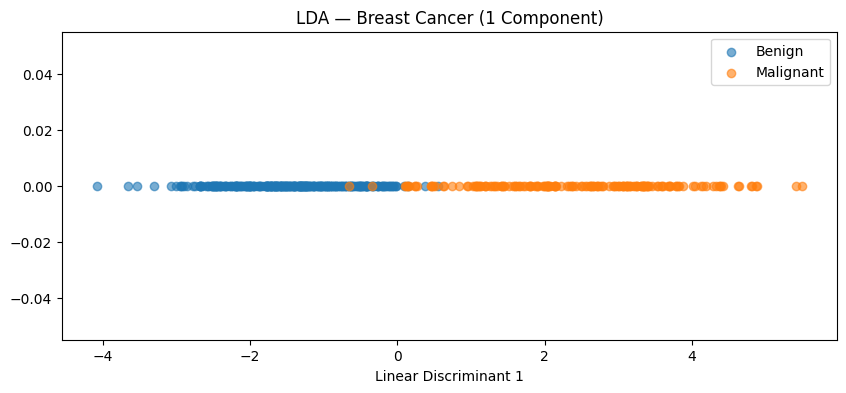

In [8]:
plt.figure(figsize=(10, 4))
plt.scatter(X_train_lda[Y_train==0], np.zeros(sum(Y_train==0)), label="Benign",    alpha=0.6)
plt.scatter(X_train_lda[Y_train==1], np.zeros(sum(Y_train==1)), label="Malignant", alpha=0.6)
plt.xlabel("Linear Discriminant 1")
plt.title("LDA — Breast Cancer (1 Component)")
plt.legend()
plt.show()

In [9]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()
clf.fit(X_train_lda, Y_train)
Y_pred = clf.predict(X_test_lda)

cm = confusion_matrix(Y_test, Y_pred)
acc = accuracy_score(Y_test, Y_pred)

print("Confusion Matrix:\n", cm)
print("Accuracy on LDA-reduced data:", round(acc, 4))

Confusion Matrix:
 [[67  4]
 [ 2 41]]
Accuracy on LDA-reduced data: 0.9474


## Conclusion
- LDA reduced 30 features to just 1 component by maximizing between-class separation and minimizing within-class spread
- Unlike PCA (unsupervised), LDA used the diagnosis labels to find the most discriminative direction
- The 1D scatter plot shows malignant and benign tumors clearly separated along a single axis
- A classifier trained on just 1 LDA component still achieved high accuracy — proving LDA preserved the most class-relevant information despite extreme compression
- Key difference from PCA: PCA maximizes variance, LDA maximizes class separation — for classification tasks, LDA's projection is more useful